# Lab Title: Why Classical Machine Learning?

## Objectives

1. To understand the evolution of classical text similarity techniques from Jaccard Similarity to TF-IDF.
2. To learn how textual data can be transformed into numerical vectors for machine learning applications.
3. To apply TF-IDF vectorization for extracting statistically important features from research paper metadata.
4. To use Cosine Similarity as a measure of document similarity.
5. To implement a K-Nearest Neighbors (KNN) recommendation system for research paper retrieval.
6. To visualize document relationships and recommendation results using bar charts and PCA projections.
7. To understand the strengths and limitations of classical machine learning approaches for text recommendation tasks.

---

# Theory

Classical Machine Learning provides efficient and interpretable techniques for solving text analysis and recommendation problems. Before the rise of deep learning and transformer-based architectures, similarity-based methods were widely used for document retrieval, classification, and recommendation.

## 1. Jaccard Similarity

Jaccard Similarity measures the overlap between two sets of words and is defined as:

$$
JS = \frac{|A \cap B|}{|A \cup B|}
$$

where:

- $A$ = set of words in document A
- $B$ = set of words in document B

It provides a simple measure of similarity based on shared terms. However, it ignores word frequency because repeated words are treated as a single occurrence.

## 2. Cosine Similarity

Cosine Similarity measures the angle between two document vectors:

$$
CS = \frac{A \cdot B}{|A||B|}
$$

Unlike Jaccard Similarity, it considers word frequencies and is therefore more informative when comparing textual documents. Documents with similar word distributions have higher cosine similarity scores.

## 3. TF-IDF (Term Frequency – Inverse Document Frequency)

TF-IDF assigns importance weights to words based on:

- **Term Frequency (TF):** Frequency of a word in a document.
- **Inverse Document Frequency (IDF):** Rarity of a word across all documents.

$$
TFIDF = TF \times IDF
$$

Words appearing in many documents receive lower weights, while unique and informative words receive higher weights. This improves document representation by emphasizing meaningful terms.

## 4. K-Nearest Neighbors (KNN)

KNN is a similarity-based learning algorithm that identifies the most similar documents to a given query document. When combined with TF-IDF vectors and Cosine Similarity, KNN can be used to recommend papers that share similar topics, methodologies, or authors.

In this experiment:

- Research paper metadata is converted into TF-IDF vectors.
- Cosine distance is used as the similarity metric.
- KNN retrieves the five nearest papers to the selected query paper.

## 5. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique used to project high-dimensional TF-IDF vectors into a two-dimensional space. This allows visual exploration of document clusters and similarity relationships.

---

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors 


paper_titles = [
    # Computer Vision Papers (1-10)
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),
    ("Cross-Modal Vector Alignment in Generative Vision Spaces", "CV", "CL", "Dr_G_Hinton"),
    ("Attention-Driven Object Detection in High-Resolution Imagery", "CV", "Transformers", "Dr_A_Vaswani"),
    ("Unsupervised Visual Representation via Contrastive Residuals", "CV", "CL", "Dr_G_Hinton"),
    ("Geometry-Aware Convolutions for 3D Point Cloud Processing", "CV", "CNNs", "Dr_J_Leskovec"),
    
    # NLP Papers (11-20)
    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),
    ("Exploring the Limits of Self-Supervised Machine Translation", "NLP", "CL", "Dr_Y_Bengio"),
    ("Dependency-Parsing Convolutions for Low-Resource Languages", "NLP", "CNNs", "Dr_Y_LeCun"),
    ("Token-Free Language Representations via Character-Level Processing", "NLP", "Transformers", "Dr_Y_Bengio"),
    ("Retrieval-Augmented Transformers for Dynamic Knowledge Graphs", "NLP", "Transformers", "Dr_J_Leskovec"),
    ("Evaluating Prompt Calibration Metrics in LLM Quantization", "NLP", "Transformers", "Dr_Y_Bengio"),

    # Graph AI Papers (21-30)
    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Message-Passing Frameworks for Heterogeneous Molecular Topologies", "Graph_AI", "GNNs", "Dr_G_Hinton"),
    ("Graph Convolutions Meet Vision Transformers: A Unified Review", "Graph_AI", "Transformers", "Dr_Y_LeCun"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Inductive Representation Learning on Large-Scale Social Webs", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Contrastive Node Clustering via Graph Diffusion Wavelets", "Graph_AI", "CL", "Dr_G_Hinton"),
    ("Deep Generative Models for Graph Structure Deconvolution", "Graph_AI", "CNNs", "Dr_Y_LeCun"),
    ("Scalable Graph Neural Architecture Search via Gradient Descent", "Graph_AI", "GNNs", "Dr_Y_Bengio")
]

# Convert the raw nested sequence into a structured Pandas DataFrame
columns = ["Title", "Domain_Code", "Methodology_Code", "Primary_Author"]
df = pd.DataFrame(paper_titles, columns=columns)
df.insert(0, 'Paper_ID', range(1, len(df) + 1))

# Optionally save to disk to inspect structural data
df.to_csv('research_papers_network.csv', index=False)


# Combine descriptive features and text metadata fields into a singular text profile string
df['Features_Corpus'] = df['Title'] + " " + df['Domain_Code'] + " " + df['Methodology_Code'] + " " + df['Primary_Author']

# Lowercase everything to ensure string consistency and eliminate casing bias
df['Features_Corpus'] = df['Features_Corpus'].str.lower()


vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b\w+\b')

tfidf_matrix = vectorizer.fit_transform(df['Features_Corpus'])


knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

target_title = "Unsupervised Visual Representation via Contrastive Residuals"
query_idx = df[df['Title'] == target_title].index[0]

# Query the KNN tree to get spatial coordinate arrays for closest nodes
distances, indices = knn_model.kneighbors(tfidf_matrix[query_idx])

# Display machine learning recommendations
print(f"Target Input Paper: '{df.iloc[query_idx]['Title']}'")
print("=" * 95)

# Loop starting from index 1 (skipping 0 because index 0 is always the target paper itself)
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    cosine_distance = distances[0][rank]
    
    # Mathematical transformation: Similarity = 1 - Distance
    similarity_score = 1 - cosine_distance
    
    print("Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]")





Target Input Paper: 'Unsupervised Visual Representation via Contrastive Residuals'
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]


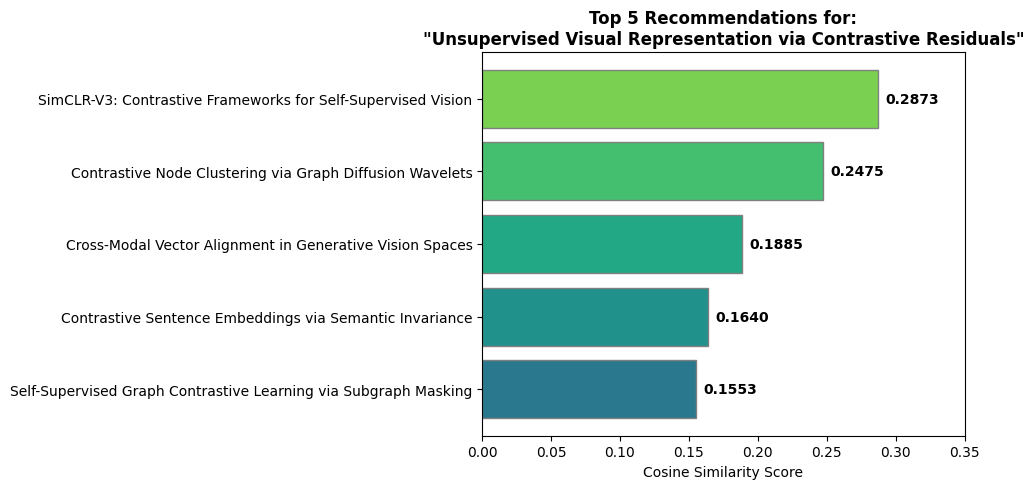

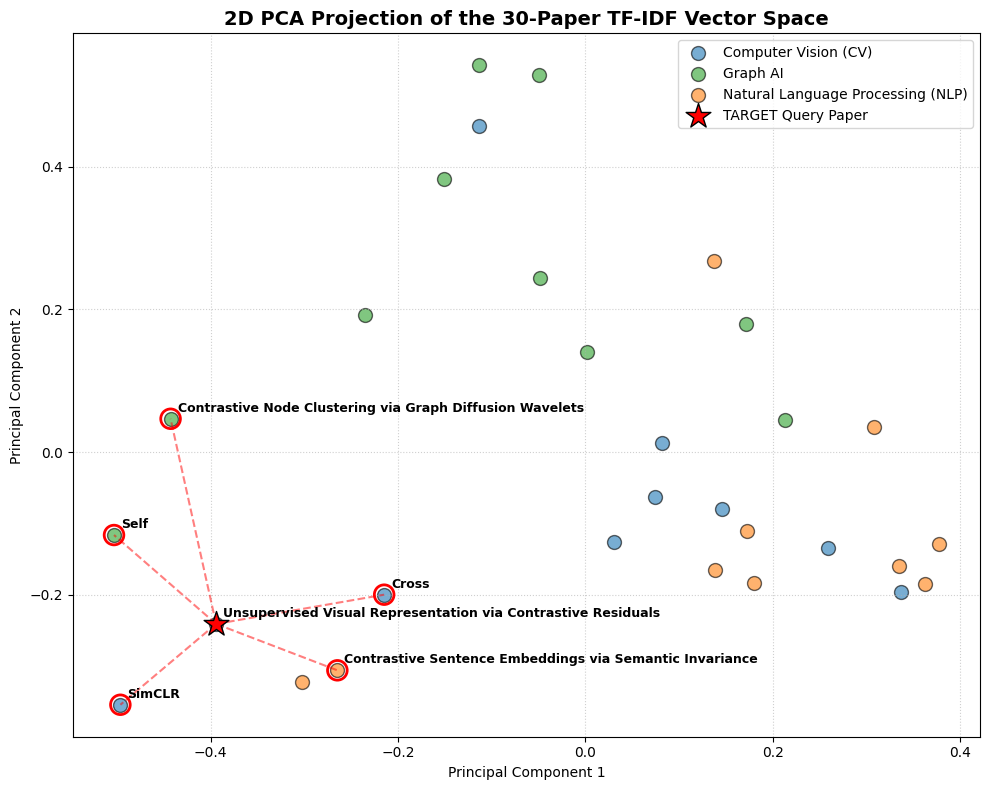

Visualizations successfully compiled and saved to disk.


In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# VISUALIZATION MODULE 1: HORIZONTAL BAR CHART OF TOP SIMILARITIES
# ==============================================================================
rec_titles = []
rec_scores = []
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    sim_score = 1 - distances[0][rank]
    rec_titles.append(df.iloc[match_idx]['Title'])
    rec_scores.append(sim_score)

# Sort recommendations to guarantee sorted descending presentation
rec_data = sorted(zip(rec_titles, rec_scores), key=lambda x: x[1])
sorted_titles, sorted_scores = zip(*rec_data)

# Create Plot canvas using standard subplots to avoid truncation
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_scores)))
bars = ax.barh(sorted_titles, sorted_scores, color=colors, edgecolor='grey')

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 Recommendations for:\n"{target_title}"', fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.35)

# Append raw score values cleanly onto the tips of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


# ==============================================================================
# VISUALIZATION MODULE 2: 2D GEOMETRIC PCA PROJECTION 
# ==============================================================================
# Compress sparse matrix coordinates to a 2D dense layout plane
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['X'], df['Y'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# Distribute colors cleanly mapping across academic domain codes
domain_colors = {'CV': '#1f77b4', 'NLP': '#ff7f0e', 'Graph_AI': '#2ca02c'}
domain_labels = {'CV': 'Computer Vision (CV)', 'NLP': 'Natural Language Processing (NLP)', 'Graph_AI': 'Graph AI'}

for domain, group in df.groupby('Domain_Code'):
    ax.scatter(group['X'], group['Y'], label=domain_labels[domain], 
               color=domain_colors[domain], s=100, alpha=0.6, edgecolors='black')

# Anchor and highlight target paper index
target_x, target_y = df.iloc[query_idx]['X'], df.iloc[query_idx]['Y']
ax.scatter(target_x, target_y, color='red', marker='*', s=350, 
           label='TARGET Query Paper', edgecolors='black', zorder=5)

# Draw spatial connection lines to matching neighbors
neighbor_indices = indices[0][1:]
for idx in neighbor_indices:
    nx, ny = df.iloc[idx]['X'], df.iloc[idx]['Y']
    ax.scatter(nx, ny, facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=4)
    ax.plot([target_x, nx], [target_y, ny], color='red', linestyle='--', alpha=0.5, zorder=3)

# Overlay short acronym annotations onto the vector nodes
for i, row in df.iterrows():
    if i == query_idx or i in neighbor_indices:
        short_name = row['Title'].split(':')[0].split('-')[0]
        ax.annotate(short_name, (row['X'], row['Y']), textcoords="offset points", 
                    xytext=(5,5), ha='left', fontsize=9, weight='bold')

ax.set_title('2D PCA Projection of the 30-Paper TF-IDF Vector Space', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig('vector_space_projection.png', dpi=300)
plt.show()
plt.close()

print("Visualizations successfully compiled and saved to disk.")

# Discussion

A dataset containing thirty synthetic research papers from the domains of Computer Vision (CV), Natural Language Processing (NLP), and Graph AI was created. Each paper included metadata such as title, domain, methodology, and primary author.

The metadata fields were combined into a single textual representation and transformed into numerical vectors using TF-IDF vectorization. This process assigned greater importance to distinctive terms while reducing the influence of common terms.

A KNN model using cosine distance was then trained on the TF-IDF vectors. The paper **"Unsupervised Visual Representation via Contrastive Residuals"** was selected as the query paper. The model successfully retrieved the five most similar papers based on content similarity.

Two visualizations were generated:

### 1. Horizontal Bar Chart

- Displayed the similarity scores of the top recommended papers.
- Allowed easy comparison of recommendation strength.
- Higher similarity scores indicated stronger relationships with the query paper.

### 2. PCA Projection

- Reduced the TF-IDF feature space to two dimensions.
- Showed clustering behavior among papers from similar domains.
- Highlighted the query paper and its nearest neighbors.
- Illustrated how documents with related features tend to occupy nearby positions in vector space.

The experiment demonstrates how classical machine learning techniques can effectively perform recommendation tasks without requiring large datasets or computationally expensive deep learning models. The results were interpretable and computationally efficient.

However, these methods rely heavily on exact word occurrences and statistical patterns. They cannot fully understand semantic meaning or contextual relationships between words, which limits their performance compared to modern transformer-based models.

---

# Conclusion

This laboratory experiment successfully demonstrated the importance and effectiveness of classical machine learning techniques in text recommendation systems. Starting from basic similarity concepts and progressing to TF-IDF weighting and KNN retrieval, the experiment showed how textual information can be transformed into meaningful numerical representations for machine learning.

TF-IDF improved document representation by assigning statistical importance to words, while KNN utilized cosine similarity to identify closely related research papers. The generated visualizations further illustrated document relationships and clustering patterns within the dataset.

Overall, the experiment highlights that classical machine learning methods remain valuable due to their simplicity, interpretability, low computational cost, and effectiveness for small to medium-sized datasets, even in an era dominated by deep learning and transformer architectures.